# Speech Emotion Recognition
This project develops a machine learning system to detect emotions (e.g., happiness, sadness, anger, fear) from speech recordings. By analyzing vocal features such as pitch, energy, and spectral characteristics, the model classifies audio clips into emotional categories.
Applications include customer service sentiment analysis, healthcare monitoring, and human-computer interaction.


In [1]:
import librosa, librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
import kagglehub
DATA_PATH = kagglehub.dataset_download("amitgm1994/ravdees-dataset")

100%|██████████| 61.8M/61.8M [00:00<00:00, 91.8MB/s]

Extracting files...


In [3]:
import os
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfccs

def prepare_dataset(data_path):
    file_paths, features, labels = [], [], []

    for root, dirs, files in os.walk(data_path):
        for f in files:
            if f.endswith(".wav"):
                parts = f.split("-")
                emotion_code = parts[2]
                emotion = emotion_map.get(emotion_code, "unknown")


                file_path = os.path.join(root, f)
                mfccs = extract_features(file_path)

                file_paths.append(file_path)
                features.append(mfccs)
                labels.append(emotion)
    df = pd.DataFrame(features)
    df["label"] = labels
    df["file_path"] = file_paths

    return df

In [4]:
df = prepare_dataset(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1168, 42)
            0          1          2          3          4          5  \
0 -322.809906  69.905876 -48.719585  28.147581 -31.788252   7.047605   
1 -670.104797  78.264435 -12.059116  24.986628  -3.598133   7.726649   
2 -644.530945  90.457047 -15.900926  29.885302  -1.442630   4.875333   
3 -570.705872  80.711525 -22.089281  31.683346 -10.534119   7.090809   
4 -450.401611  75.872002 -24.897985  11.996142 -26.807331  11.310624   

           6          7          8          9  ...        32        33  \
0 -27.072483  -0.037350 -25.989857 -11.472788  ...  1.553262 -3.511781   
1  -8.988244  -3.180261 -15.108124  -4.277107  ... -1.865566 -3.405579   
2  -9.349506  -6.550121 -16.278793  -5.044893  ... -1.957543 -4.379254   
3 -17.191553  -5.342383 -23.026972  -3.898438  ... -2.771278 -5.991355   
4 -25.394011 -13.808109 -21.465557  -9.274205  ...  2.467051  0.057839   

         34        35        36        37        38        39    label  \
0  0.057941  0.250989 

Classification Report:
               precision    recall  f1-score   support

       angry       0.62      0.50      0.55        36
     disgust       0.49      0.64      0.55        36
     fearful       0.53      0.44      0.48        36
       happy       0.62      0.37      0.46        35
     neutral       0.47      0.39      0.42        18
         sad       0.44      0.65      0.53        37
   surprised       0.61      0.64      0.62        36

    accuracy                           0.53       234
   macro avg       0.54      0.52      0.52       234
weighted avg       0.54      0.53      0.53       234



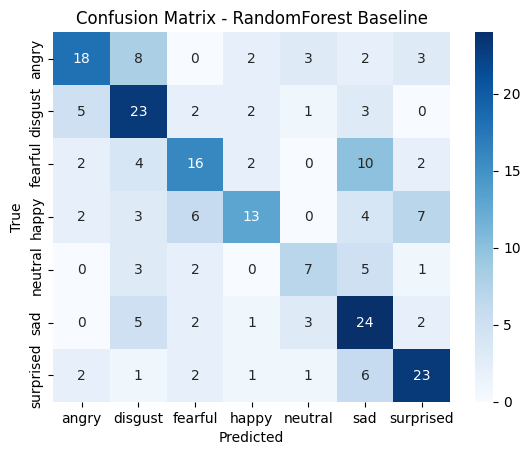

In [5]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RandomForest Baseline")
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# Prepare features and labels
X = df.drop(columns=["label", "file_path"]).values
y = df["label"].values

# Encode labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Reshape for CNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN model
model = models.Sequential([
    layers.Conv1D(64, kernel_size=5, strides=1, activation="relu", input_shape=(40,1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(128, kernel_size=5, strides=1, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(encoder.classes_), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2494 - loss: 2.3430 - val_accuracy: 0.2350 - val_loss: 2.0094
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3933 - loss: 1.5312 - val_accuracy: 0.2906 - val_loss: 1.8268
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4915 - loss: 1.3961 - val_accuracy: 0.3590 - val_loss: 1.6865
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5675 - loss: 1.1653 - val_accuracy: 0.3974 - val_loss: 1.5578
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5591 - loss: 1.1761 - val_accuracy: 0.4231 - val_loss: 1.5945
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6543 - loss: 0.9968 - val_accuracy: 0.3547 - val_loss: 1.6607
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6225 - loss: 1.0126 - val_accuracy: 0.4957 - val_loss: 1.4595
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7042 - loss: 0.8761 - val_accuracy: 0.4872 - v

In [7]:
model.save("emotion_model.h5")
np.save("classes.npy", encoder.classes_)

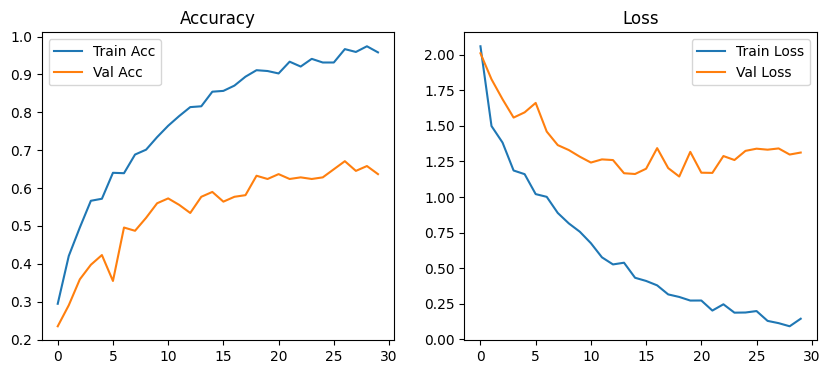

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()